In [14]:
import json
import pathlib
import random
import re
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from joblib import Parallel, delayed
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from unidecode import unidecode

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
CORES = sns.color_palette("muted")

print("Imports OK")

Imports OK


In [15]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Carrega dados processados pelo notebook 02_nlp
df = pd.read_csv("motor1_analise_final_clean.csv", encoding="utf-8-sig")
df_tfidf = pd.read_csv("tfidf_final_clean.csv", encoding="utf-8-sig")

# Reconstrói X_tfidf e vocab a partir do df_tfidf
vocab = df_tfidf.columns.tolist()
X_tfidf_arr = df_tfidf.values
X = X_tfidf_arr

# Compatibilidade com variáveis usadas nos blocos de análise
import scipy.sparse as sp
X_tfidf = sp.csr_matrix(X_tfidf_arr)

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
CORES = sns.color_palette("muted")

print(f"Notícias carregadas: {len(df)}")
print(f"Features TF-IDF: {len(vocab)}")
df.head(3)


Notícias carregadas: 189
Features TF-IDF: 576


,url,titulo,descricao,categoria,data,grupo,texto_limpo,n_tokens,n_unicos
0,https://motor1.uol.com.br/news/796755/novos-ri...,BYD Dolphin: os novos elétricos que podem amea...,"GAC, MG, DFM e Arcfox apostam em preço, autono...",Análise,2026-05-24T15:00:00+00:00,Elétrico,byd dolphin novos eletricos podem ameacar aind...,21,19
1,https://motor1.uol.com.br/news/796498/vendas-r...,Omoda 5 entra no top 10 britânico em mês de fo...,"Ford Puma lidera, mas o grande destaque do mer...",Análise,2026-05-24T12:00:00+00:00,Elétrico,omoda entra top britanico mes forte alta eletr...,17,15
2,https://motor1.uol.com.br/news/796725/citroen-...,O Citroën 2CV está quase pronto para voltar: e...,O lendário Citroën 2CV está de volta. Inspirad...,Análise,2026-05-23T15:00:00+00:00,Elétrico,citroen quase pronto voltar eis imagem lendari...,21,20


## 10. Classificação — Random Forest

In [27]:
le = LabelEncoder()
y = le.fit_transform(df["grupo"])
X = X_tfidf.toarray()

print("Classes:", le.classes_)
print("Distribuição:", dict(zip(le.classes_, np.bincount(y))))

contagem_y = np.bincount(y)
classes_validas = np.where(contagem_y >= 5)[0]
mask_valida = np.isin(y, classes_validas)

X_v = X[mask_valida]
y_v = y[mask_valida]

print(f"Amostras após filtro de classe mínima: {len(y_v)}")

Classes: ['Combustão' 'Elétrico' 'Geral' 'Misto/Híbrido']
Distribuição: {'Combustão': np.int64(9), 'Elétrico': np.int64(76), 'Geral': np.int64(93), 'Misto/Híbrido': np.int64(11)}
Amostras após filtro de classe mínima: 189


In [17]:
X_tmp, X_teste, y_tmp, y_teste = train_test_split(
    X_v, y_v, test_size=0.2, random_state=42, stratify=y_v
)
X_treino, X_calib, y_treino, y_calib = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"Treino: {X_treino.shape[0]} | Calibração: {X_calib.shape[0]} | Teste: {X_teste.shape[0]}")

Treino: 113 | Calibração: 38 | Teste: 38


In [18]:
ns = [50, 100, 200, 300, 500]
resultados_calib = []

for n in ns:
    modelo = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    modelo.fit(X_treino, y_treino)
    f1_c = f1_score(y_calib, modelo.predict(X_calib), average="macro", zero_division=0)
    resultados_calib.append({"n_estimators": n, "F1_macro_calib": f1_c})
    print(f"n={n:3d} -> F1-macro calib = {f1_c:.4f}")

df_calib = pd.DataFrame(resultados_calib)
melhor_n = int(df_calib.loc[df_calib["F1_macro_calib"].idxmax(), "n_estimators"])
print(f"Melhor n_estimators: {melhor_n}")
df_calib

n= 50 -> F1-macro calib = 0.4123
n=100 -> F1-macro calib = 0.3963
n=200 -> F1-macro calib = 0.3963
n=300 -> F1-macro calib = 0.3963
n=500 -> F1-macro calib = 0.4123
Melhor n_estimators: 50


,n_estimators,F1_macro_calib
0,50,0.412338
1,100,0.396296
2,200,0.396296
3,300,0.396296
4,500,0.412338


In [19]:
clf = RandomForestClassifier(
    n_estimators=melhor_n,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)
clf.fit(X_treino, y_treino)
y_pred = clf.predict(X_teste)

nomes_classes = le.classes_[[c for c in np.unique(y_v)]]

print("Métricas no conjunto de teste")
print(f"Acurácia : {accuracy_score(y_teste, y_pred):.4f}")
print(f"F1 Macro : {f1_score(y_teste, y_pred, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_teste, y_pred, target_names=nomes_classes, zero_division=0))

Métricas no conjunto de teste
Acurácia : 0.7632
F1 Macro : 0.3963

               precision    recall  f1-score   support

    Combustão       0.00      0.00      0.00         2
     Elétrico       0.83      0.67      0.74        15
        Geral       0.73      1.00      0.84        19
Misto/Híbrido       0.00      0.00      0.00         2

     accuracy                           0.76        38
    macro avg       0.39      0.42      0.40        38
 weighted avg       0.69      0.76      0.71        38



In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(
    RandomForestClassifier(
        n_estimators=melhor_n,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    X_treino,
    y_treino,
    cv=cv,
    scoring="f1_macro",
)

print(f"Cross-val F1-macro: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
print(f"Scores por fold: {[f'{s:.4f}' for s in scores_cv]}")

Cross-val F1-macro: 0.3949 ± 0.0462
Scores por fold: ['0.4096', '0.4397', '0.3912', '0.3083', '0.4259']


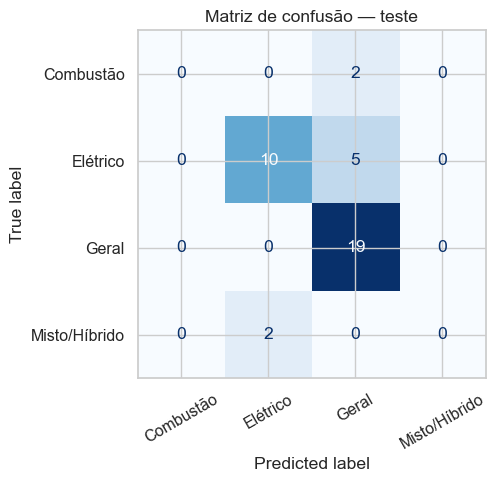

Salvo: fig_confusion_matrix_clean.png


In [21]:
cm = confusion_matrix(y_teste, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=nomes_classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title("Matriz de confusão — teste")
plt.tight_layout()
plt.savefig("fig_confusion_matrix_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print("Salvo: fig_confusion_matrix_clean.png")

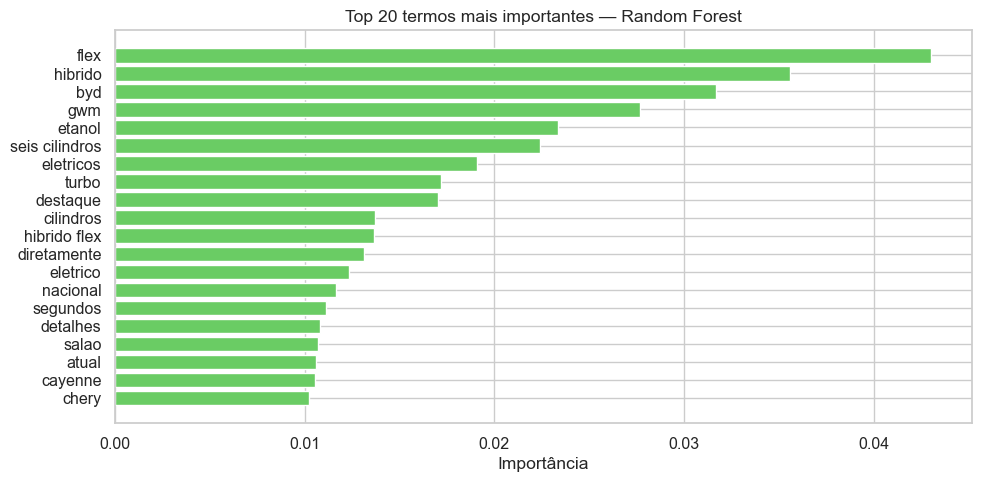

Salvo: fig_feature_importance_clean.png


In [22]:
importancias = pd.Series(clf.feature_importances_, index=vocab)
top_imp = importancias.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color=CORES[2])
ax.set_title("Top 20 termos mais importantes — Random Forest")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.savefig("fig_feature_importance_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print("Salvo: fig_feature_importance_clean.png")

## 11. Regressão — volume lexical

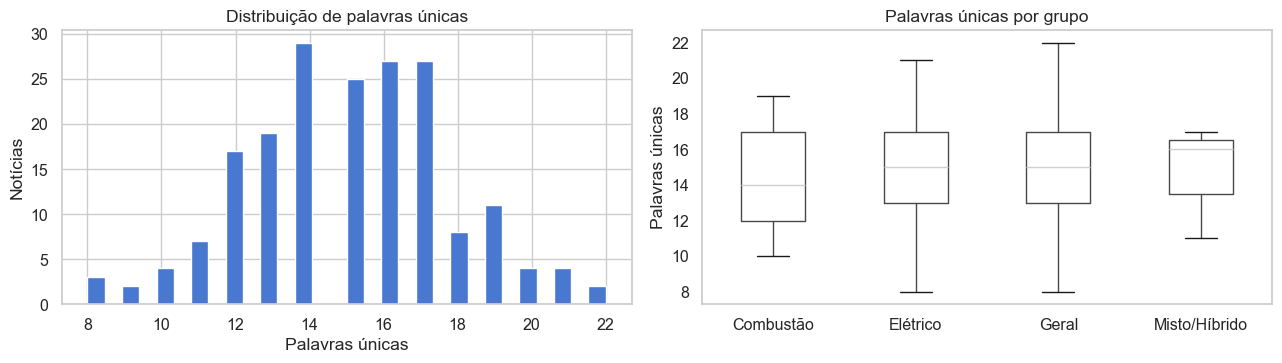

In [23]:
y_reg = df["n_unicos"].values
X_reg = X

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_reg, bins=30, color=CORES[0], edgecolor="white")
axes[0].set_title("Distribuição de palavras únicas")
axes[0].set_xlabel("Palavras únicas")
axes[0].set_ylabel("Notícias")

df.boxplot(column="n_unicos", by="grupo", ax=axes[1], grid=False)
axes[1].set_title("Palavras únicas por grupo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Palavras únicas")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [24]:
X_tmp_r, X_teste_r, y_tmp_r, y_teste_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_treino_r, X_calib_r, y_treino_r, y_calib_r = train_test_split(
    X_tmp_r, y_tmp_r, test_size=0.25, random_state=42
)

ns_reg = [50, 100, 200, 400]
modelos_reg = {}
resultados_reg = []

for n in ns_reg:
    modelo = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_r, y_treino_r)
    mae = mean_absolute_error(y_calib_r, modelo.predict(X_calib_r))
    resultados_reg.append({"n_estimators": n, "MAE_calib": mae})
    modelos_reg[n] = modelo
    print(f"n={n:3d} -> MAE calib = {mae:.2f}")

df_reg = pd.DataFrame(resultados_reg)
melhor_n_reg = int(df_reg.loc[df_reg["MAE_calib"].idxmin(), "n_estimators"])
print(f"Melhor n_estimators: {melhor_n_reg}")

pred_r = modelos_reg[melhor_n_reg].predict(X_teste_r)
mae_teste = mean_absolute_error(y_teste_r, pred_r)
r2_teste = r2_score(y_teste_r, pred_r)

print(f"MAE no teste: {mae_teste:.2f} palavras")
print(f"R² no teste : {r2_teste:.4f}")

n= 50 -> MAE calib = 1.97
n=100 -> MAE calib = 1.95
n=200 -> MAE calib = 1.95
n=400 -> MAE calib = 1.96
Melhor n_estimators: 200
MAE no teste: 2.30 palavras
R² no teste : -0.3155


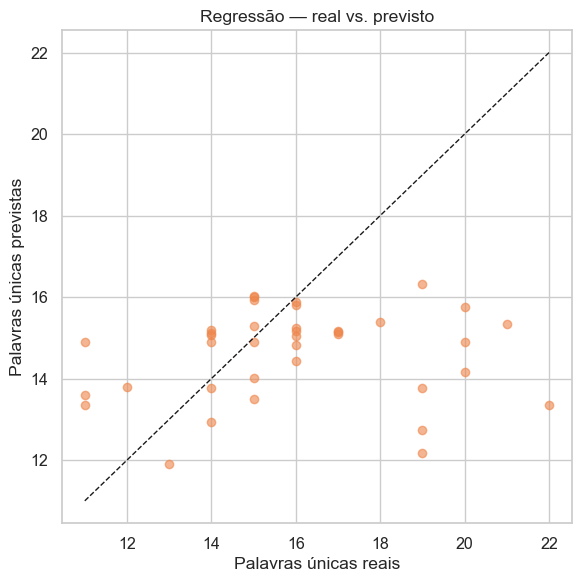

,real,previsto
0,15,14.9
1,22,13.4
2,13,11.9
3,16,14.4
4,14,15.2
5,21,15.3
6,20,15.8
7,20,14.2
8,16,15.2
9,15,15.9


In [25]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_teste_r, pred_r, alpha=0.6, color=CORES[1])

limite_min = min(y_teste_r.min(), pred_r.min())
limite_max = max(y_teste_r.max(), pred_r.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], "k--", linewidth=1)

ax.set_title("Regressão — real vs. previsto")
ax.set_xlabel("Palavras únicas reais")
ax.set_ylabel("Palavras únicas previstas")
plt.tight_layout()
plt.show()

pd.DataFrame({"real": y_teste_r, "previsto": pred_r.round(1)}).head(10)

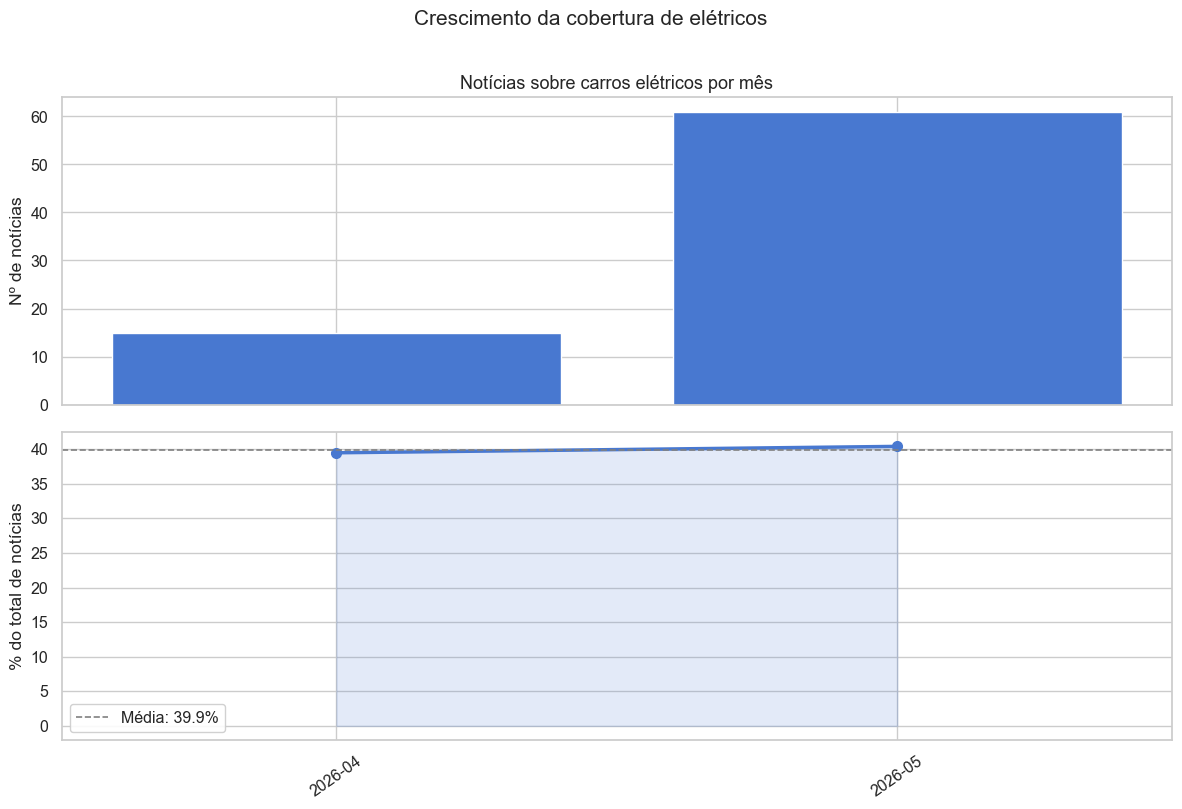

In [30]:
# ============================================================
#  ANÁLISE 1 — Evolução mensal: crescimento dos elétricos
# ============================================================

# ensure we have ano_mes on the dataframe
df["data"] = pd.to_datetime(df["data"], utc=True, errors="coerce")
df["ano_mes"] = df["data"].dt.to_period("M").astype(str)

temporal = (
    df.groupby(["ano_mes", "grupo"])
    .size()
    .reset_index(name="n")
)

total_mes = temporal.groupby("ano_mes")["n"].sum().rename("total")
temporal = temporal.join(total_mes, on="ano_mes")
temporal["proporcao"] = temporal["n"] / temporal["total"] * 100

ev_temporal = (
    temporal[temporal["grupo"] == "Elétrico"]
    .set_index("ano_mes")
    .sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- subplot 1: volume absoluto ---
axes[0].bar(ev_temporal.index, ev_temporal["n"],
            color=CORES[0], edgecolor="white")
axes[0].set_title("Notícias sobre carros elétricos por mês", fontsize=13)
axes[0].set_ylabel("Nº de notícias")

# --- subplot 2: proporção ---
axes[1].plot(ev_temporal.index, ev_temporal["proporcao"],
             marker="o", color=CORES[0], linewidth=2.5, markersize=7)
axes[1].fill_between(ev_temporal.index, ev_temporal["proporcao"],
                     alpha=0.15, color=CORES[0])
axes[1].axhline(ev_temporal["proporcao"].mean(), color="gray",
                linestyle="--", linewidth=1.2, label=f"Média: {ev_temporal['proporcao'].mean():.1f}%")
axes[1].set_ylabel("% do total de notícias")
axes[1].set_xlabel("")
axes[1].legend(framealpha=0.9)
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Crescimento da cobertura de elétricos", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("analise1_crescimento_eletricos.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

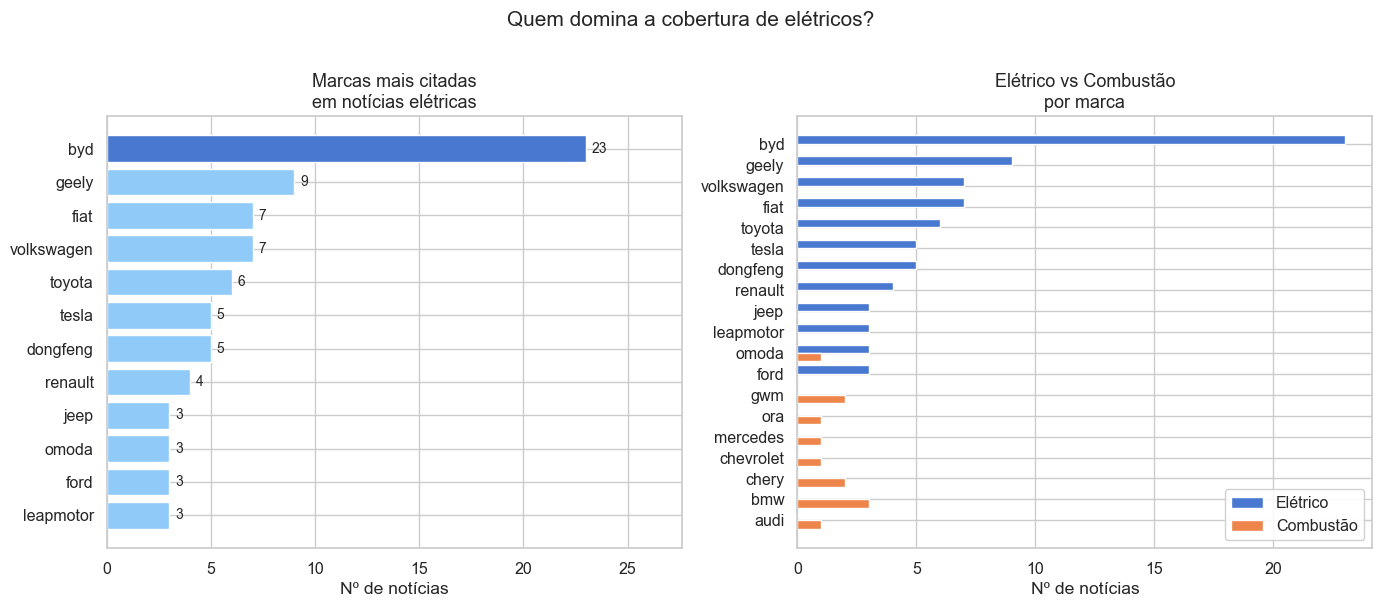

In [31]:
# ============================================================
#  ANÁLISE 2 — Marcas que dominam o tema elétrico
# ============================================================

MARCAS = [
    "toyota", "volkswagen", "vw", "chevrolet", "fiat", "honda",
    "hyundai", "ford", "renault", "jeep", "nissan", "byd", "mercedes",
    "bmw", "audi", "tesla", "caoa", "chery", "citroen", "peugeot",
    "mitsubishi", "volvo", "kia", "gwm", "ora", "haval",
    "leapmotor", "zeekr", "porsche", "dongfeng", "omoda", "jaecoo",
    "geely", "ram", "stellantis",
]

def contar_marcas(subdf):
    contagem = Counter()
    for tokens_str in subdf["texto_limpo"]:
        presentes = set(tokens_str.split()) & set(MARCAS)
        contagem.update(presentes)
    return pd.Series(contagem)

df_ev   = df[df["grupo"] == "Elétrico"]
df_comb = df[df["grupo"] == "Combustão"]

marcas_ev   = contar_marcas(df_ev).sort_values(ascending=False).head(12)
marcas_comb = contar_marcas(df_comb).sort_values(ascending=False).head(12)

# --- todas as marcas que aparecem em pelo menos um dos grupos ---
todas = sorted(set(marcas_ev.index) | set(marcas_comb.index))
comp = pd.DataFrame({
    "Elétrico"  : marcas_ev.reindex(todas, fill_value=0),
    "Combustão" : marcas_comb.reindex(todas, fill_value=0),
}).sort_values("Elétrico", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- subplot 1: ranking elétrico ---
marcas_ev_plot = marcas_ev.sort_values(ascending=True)
cores_barras = [CORES[0] if m == "byd" else "#90CAF9" for m in marcas_ev_plot.index]

bars = axes[0].barh(marcas_ev_plot.index, marcas_ev_plot.values,
                    color=cores_barras, edgecolor="white")
axes[0].bar_label(bars, padding=4, fontsize=10)
axes[0].set_title("Marcas mais citadas\nem notícias elétricas", fontsize=13)
axes[0].set_xlabel("Nº de notícias")
axes[0].set_xlim(0, marcas_ev_plot.max() * 1.2)

# --- subplot 2: comparação elétrico vs combustão ---
x = np.arange(len(comp))
w = 0.4

axes[1].barh(x + w/2, comp["Elétrico"],  height=w, color=CORES[0], label="Elétrico",  edgecolor="white")
axes[1].barh(x - w/2, comp["Combustão"], height=w, color=CORES[1], label="Combustão", edgecolor="white")
axes[1].set_yticks(x)
axes[1].set_yticklabels(comp.index)
axes[1].set_title("Elétrico vs Combustão\npor marca", fontsize=13)
axes[1].set_xlabel("Nº de notícias")
axes[1].legend(framealpha=0.9)

plt.suptitle("Quem domina a cobertura de elétricos?", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("analise2_marcas_eletrico.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

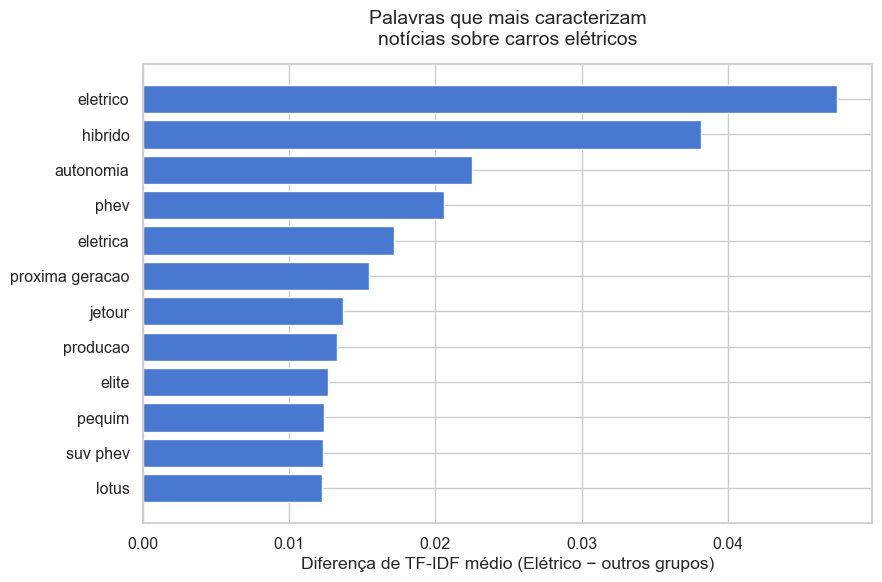

In [35]:
# ============================================================
#  ANÁLISE 3 — Vocabulário exclusivo das notícias elétricas
#  (versão corrigida)
# ============================================================

tfidf_ev  = df_tfidf[df["grupo"] == "Elétrico"].mean()
tfidf_out = df_tfidf[df["grupo"] != "Elétrico"].mean()

exclusividade = (tfidf_ev - tfidf_out).sort_values(ascending=False)

# --- remove marcas e modelos (já cobertos na análise 2) ---
MARCAS_REMOVER = {
    "byd", "geely", "tesla", "dongfeng", "leapmotor", "nissan",
    "omoda", "gwm", "ora", "zeekr", "volkswagen", "vw",
    "fiat", "toyota", "honda", "renault", "jeep", "chevrolet",
    "ford", "hyundai", "bmw", "audi", "mercedes", "volvo",
    "kia", "chery", "citroen", "peugeot", "mitsubishi", "ram",
    "stellantis", "caoa", "haval", "porsche","omoda jaecoo",
    # modelos específicos
    "dolphin", "sonic", "avenger", "argo", "tracker", "pulse",
    "kardian", "nivus", "toro", "strada", "creta", "corolla",
    # bigramas de marca/modelo
    "byd dolphin", "dolphin mini", "chevrolet sonic", "jeep avenger",
    "gwm ora", "gwm tank",
}

# --- remove palavras genéricas que não caracterizam o tema ---
GENERICOS_REMOVER = {
    "mini", "proxima", "model", "serie", "nacional",
    "faz", "primeiro", "segunda", "nova", "novo",
    "grande", "pequeno", "alta", "baixo",
    "mil", "motoristas", "pais", "bilhao", "visual", "cnh",
    "cupe", "volta", "top", "marco", "antecipa",
}

excl_filtrado = exclusividade[
    ~exclusividade.index.isin(MARCAS_REMOVER | GENERICOS_REMOVER)
]

# --- remove duplicatas por prefixo (ex: "eletrico" e "eletricos") ---
def remover_prefixos(series: pd.Series, min_len: int = 5) -> pd.Series:
    """Mantém apenas o token mais curto quando um é prefixo do outro."""
    tokens = series.index.tolist()
    remover = set()
    for i, t1 in enumerate(tokens):
        for t2 in tokens[i + 1:]:
            curto, longo = (t1, t2) if len(t1) <= len(t2) else (t2, t1)
            if len(curto) >= min_len and longo.startswith(curto):
                remover.add(longo)
    return series[~series.index.isin(remover)]

excl_filtrado = remover_prefixos(excl_filtrado)

top_pos = excl_filtrado[excl_filtrado > 0].head(12)   # elétrico
top_neg = excl_filtrado[excl_filtrado < 0].tail(10)   # combustão/outros

# substitui o fig, axes por figura única
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_pos.index[::-1], top_pos.values[::-1],
        color=CORES[0], edgecolor="white")
ax.set_title("Palavras que mais caracterizam\nnotícias sobre carros elétricos",
             fontsize=14, pad=14)
ax.set_xlabel("Diferença de TF-IDF médio (Elétrico − outros grupos)")

plt.tight_layout()
plt.savefig("analise3_vocabulario_eletrico.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

n= 50 -> F1 calib = 0.6400
n=100 -> F1 calib = 0.5833
n=200 -> F1 calib = 0.6667
n=300 -> F1 calib = 0.6667
n=500 -> F1 calib = 0.7200

Melhor n_estimators : 500
Acurácia no teste   : 92.1%
F1 no teste         : 88.9%

              precision    recall  f1-score   support

      Outros       0.88      1.00      0.94        23
    Elétrico       1.00      0.80      0.89        15

    accuracy                           0.92        38
   macro avg       0.94      0.90      0.91        38
weighted avg       0.93      0.92      0.92        38

Cross-val F1: 51.0% ± 12.6%


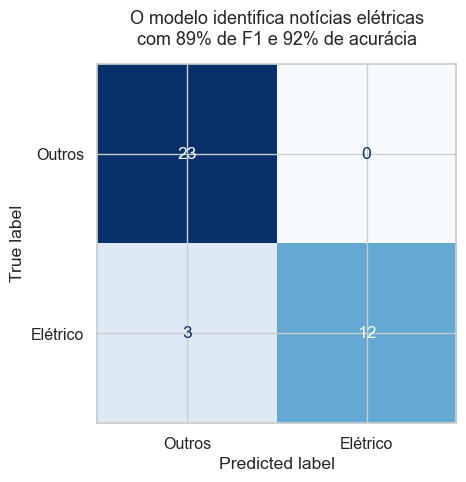

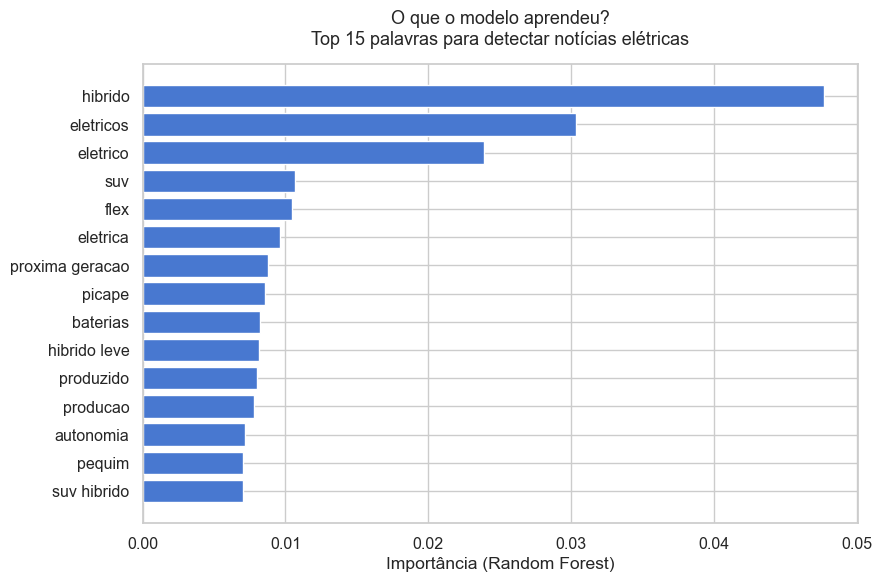

In [36]:
# ============================================================
#  ANÁLISE 4 — O modelo consegue identificar notícias elétricas?
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# --- alvo binário: Elétrico vs Resto ---
y_bin = (df["grupo"] == "Elétrico").astype(int).values
X_bin = X_tfidf_arr

X_tmp, X_teste, y_tmp, y_teste = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)
X_treino, X_calib, y_treino, y_calib = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

# --- calibração ---
ns = [50, 100, 200, 300, 500]
modelos_bin = {}
resultados_bin = []

for n in ns:
    m = RandomForestClassifier(
        n_estimators=n, class_weight="balanced",
        random_state=42, n_jobs=-1
    )
    m.fit(X_treino, y_treino)
    f1 = f1_score(y_calib, m.predict(X_calib), zero_division=0)
    resultados_bin.append((n, f1))
    modelos_bin[n] = m
    print(f"n={n:3d} -> F1 calib = {f1:.4f}")

melhor_n = max(resultados_bin, key=lambda x: x[1])[0]
clf_bin  = modelos_bin[melhor_n]
y_pred   = clf_bin.predict(X_teste)

acc = accuracy_score(y_teste, y_pred)
f1  = f1_score(y_teste, y_pred, zero_division=0)

print(f"\nMelhor n_estimators : {melhor_n}")
print(f"Acurácia no teste   : {acc:.1%}")
print(f"F1 no teste         : {f1:.1%}")
print()
print(classification_report(y_teste, y_pred, target_names=["Outros", "Elétrico"]))

# --- validação cruzada ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(
    RandomForestClassifier(
        n_estimators=melhor_n, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    X_treino, y_treino, cv=cv, scoring="f1"
)
print(f"Cross-val F1: {scores_cv.mean():.1%} ± {scores_cv.std():.1%}")

# --- figura 1: matriz de confusão ---
cm = confusion_matrix(y_teste, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Outros", "Elétrico"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(
    f"O modelo identifica notícias elétricas\n"
    f"com {f1:.0%} de F1 e {acc:.0%} de acurácia",
    fontsize=13, pad=14
)
plt.tight_layout()
plt.savefig("analise4a_confusion_eletrico.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

# --- figura 2: top palavras aprendidas pelo modelo ---
importancias = pd.Series(clf_bin.feature_importances_, index=vocab)

# remove marcas para focar no vocabulário temático
importancias_filtradas = importancias[
    ~importancias.index.isin(MARCAS_REMOVER | GENERICOS_REMOVER)
]
top20 = importancias_filtradas.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color=CORES[0], edgecolor="white")
ax.set_title(
    "O que o modelo aprendeu?\nTop 15 palavras para detectar notícias elétricas",
    fontsize=13, pad=14
)
ax.set_xlabel("Importância (Random Forest)")
plt.tight_layout()
plt.savefig("analise4b_feature_importance.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

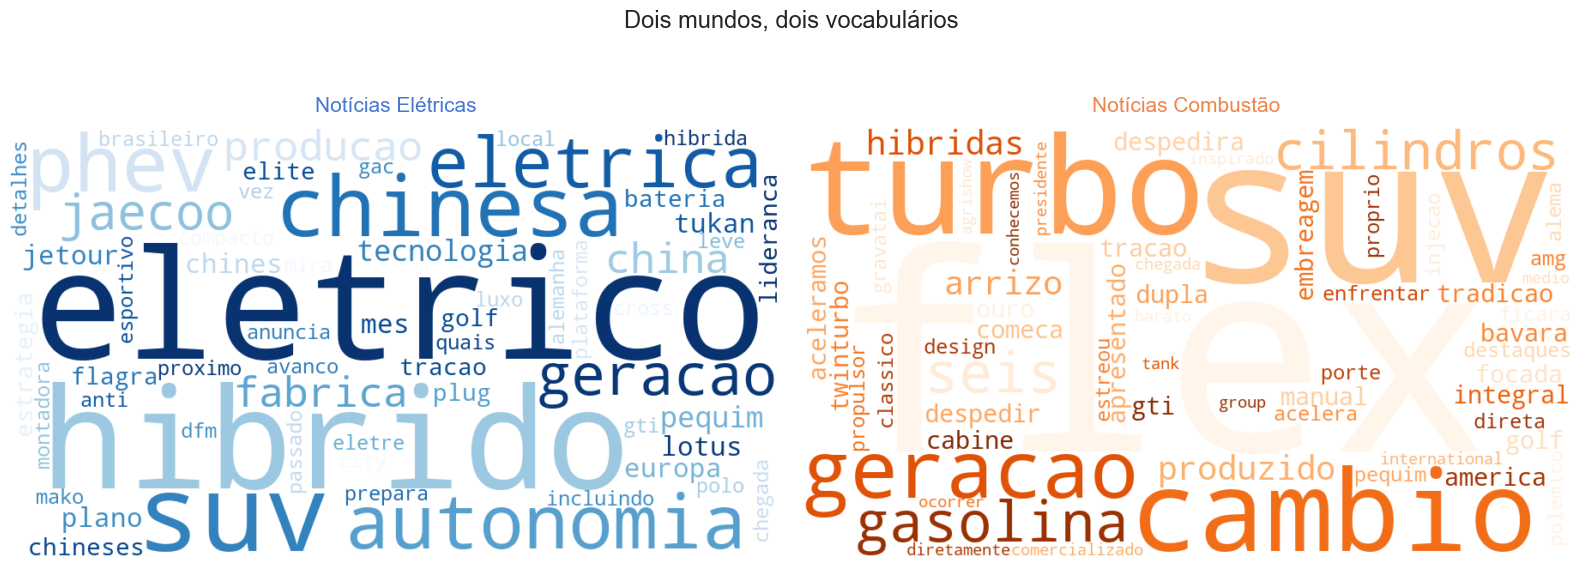

In [39]:
# ============================================================
#  ANÁLISE 5 — Wordcloud comparativa: Elétrico vs Combustão
# ============================================================

from wordcloud import WordCloud

df_ev   = df[df["grupo"] == "Elétrico"]
df_comb = df[df["grupo"] == "Combustão"]

texto_ev   = " ".join(df_ev["texto_limpo"])
texto_comb = " ".join(df_comb["texto_limpo"])

# --- remove marcas e genéricos para focar no vocabulário temático ---
SW_TOTAL = set(stopwords.words("portuguese"))
GENERICOS_REMOVER |= {
    # genéricos jornalísticos
    "antes", "novos", "ainda", "breve", "feito", "mostra",
    "salao", "linha", "abril", "lidera", "inedita", "rivais",
    "testes", "recorde", "forte", "aposta", "ranking",
    # tipos de carroçaria (já cobertos pela narrativa)
    "picape", "hatch", "seda",
    # combustão — genéricos
    "limitada", "destaque", "atual", "duas", "tendo",
    "partir", "lugar", "continuara", "classe", "entanto",
    "literalmente", "chave", "telao", "curvo", "norte",
}
REMOVER = MARCAS_REMOVER | GENERICOS_REMOVER | SW_TOTAL

def filtrar_texto(texto: str) -> str:
    return " ".join(
        t for t in texto.split()
        if t not in REMOVER and len(t) > 2
    )

texto_ev_filtrado   = filtrar_texto(texto_ev)
texto_comb_filtrado = filtrar_texto(texto_comb)

# --- wordclouds ---
wc_ev = WordCloud(
    width=900, height=500,
    background_color="white",
    colormap="Blues",
    max_words=60,
    collocations=False,
).generate(texto_ev_filtrado)

wc_comb = WordCloud(
    width=900, height=500,
    background_color="white",
    colormap="Oranges",
    max_words=60,
    collocations=False,
).generate(texto_comb_filtrado)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_ev, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Notícias Elétricas", fontsize=15, pad=12, color=CORES[0])

axes[1].imshow(wc_comb, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Notícias Combustão", fontsize=15, pad=12, color=CORES[1])

plt.suptitle("Dois mundos, dois vocabulários", fontsize=17, y=1.02)
plt.tight_layout()
plt.savefig("analise5_wordcloud_comparativa.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

## 12. Exportação final

In [26]:
colunas = [
    "url", "titulo", "descricao", "categoria", "data", "grupo",
    "texto_limpo", "n_tokens", "n_unicos",
]

df[colunas].to_csv("motor1_analise_final_clean.csv", index=False, encoding="utf-8-sig")
df_tfidf.to_csv("tfidf_final_clean.csv", index=False, encoding="utf-8-sig")

sumario = df.groupby("grupo").agg(
    n_noticias=("titulo", "count"),
    media_tokens=("n_tokens", "mean"),
    media_unicos=("n_unicos", "mean"),
    mediana_tokens=("n_tokens", "median"),
).round(1)
sumario.to_csv("sumario_grupos_clean.csv", encoding="utf-8-sig")

print("Arquivos exportados:")
print("  motor1_analise_final_clean.csv")
print("  tfidf_final_clean.csv")
print("  sumario_grupos_clean.csv")
print()
print(sumario)

Arquivos exportados:
  motor1_analise_final_clean.csv
  tfidf_final_clean.csv
  sumario_grupos_clean.csv

               n_noticias  media_tokens  media_unicos  mediana_tokens
grupo                                                                
Combustão               9          15.7          14.3            16.0
Elétrico               76          17.2          14.9            17.0
Geral                  93          17.7          15.3            18.0
Misto/Híbrido          11          17.3          15.0            18.0
